Import Libraries 

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler


Load the Dataset

In [22]:
# Load dataset
df = pd.read_csv("noise_with_price.csv")
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (715, 14)


,Station,Year,Month,Day,Night,DayLimit,NightLimit,Date,StationEncoded,DayExcess,NightExcess,MeanExcess,Price_per_SqFt,Price_in_Lakhs
0,BEN01,2011,2,0.556357,-0.243566,-0.782821,-0.754469,2011-02-01,0,0.981018,0.575138,0.778078,0.03,145.38
1,BEN01,2011,3,0.556357,0.104734,-0.782821,-0.754469,2011-03-01,0,0.981018,0.758926,0.869972,0.03,89.30
2,BEN01,2011,4,0.556357,-0.069416,-0.782821,-0.754469,2011-04-01,0,0.981018,0.667032,0.824025,0.03,130.41
3,BEN01,2011,5,0.556357,-0.243566,-0.782821,-0.754469,2011-05-01,0,0.981018,0.575138,0.778078,0.03,94.91
4,BEN01,2011,6,0.734901,-0.069416,-0.782821,-0.754469,2011-06-01,0,1.081394,0.667032,0.874213,0.03,133.05


Select Features and Target
- **Features** → DayExcess, NightExcess, MeanExcess, Price_per_SqFt  
- **Target** → Price_in_Lakhs


In [23]:
features = ["DayExcess", "NightExcess", "MeanExcess", "Price_per_SqFt"]
target = "Price_in_Lakhs"

X = df[features].values
y = df[target].values


Scale Features and Target


In [24]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))


Create Sequences for LSTM
We convert data into sequences:
- Input shape → (samples, timesteps, features)  
- Target shape → (samples, 1)  
Here, we use a `window_size = 5` (last 5 rows → predict the price of the 6th row).


In [25]:
def create_sequences(X, y, window_size=5):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:(i+window_size)])
        ys.append(y[i+window_size])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, window_size=5)
print("X_seq shape:", X_seq.shape)  # (samples, 5, 4)
print("y_seq shape:", y_seq.shape)  # (samples, 1)


X_seq shape: (710, 5, 4)
y_seq shape: (710, 1)


Train-Test Split

In [26]:
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


Train set: (568, 5, 4) (568, 1)
Test set: (142, 5, 4) (142, 1)


In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler_y = MinMaxScaler()

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1))


Build the LSTM Model

In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Build model
model = keras.Sequential([
    layers.Input(shape=(5, 4)),       # timesteps=5, features=4
    layers.LSTM(64, return_sequences=False),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)  # output layer (regression)
])

# Compile
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

Train the Model


In [29]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=16,
    verbose=1
)


Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0527 - mae: 0.1778 - val_loss: 0.0467 - val_mae: 0.1788
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0302 - mae: 0.1420 - val_loss: 0.0453 - val_mae: 0.1767
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0293 - mae: 0.1346 - val_loss: 0.0452 - val_mae: 0.1746
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0291 - mae: 0.1334 - val_loss: 0.0453 - val_mae: 0.1728
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0298 - mae: 0.1349 - val_loss: 0.0435 - val_mae: 0.1694
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0306 - mae: 0.1402 - val_loss: 0.0452 - val_mae: 0.1695
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0283 - mae: 0.1319 - val_loss: 0.0425 - val_mae: 0.1686
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0297 - mae: 0.1370 - val_loss: 0.0452 - val_mae: 0.1697
Epoch 9/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0291 - mae:

Evaluate the Model

In [30]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test MAE: {mae:.4f}")


Test MAE: 0.1657


Make Predictions

In [31]:
# Predictions
y_pred_scaled = model.predict(X_test)

# Inverse transform to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

# Show first 10 predictions vs actual
for i in range(10):
    print(f"Predicted: {y_pred[i][0]:.2f}, Actual: {y_test_original[i][0]:.2f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Predicted: 0.40, Actual: 0.53
Predicted: 0.42, Actual: 0.73
Predicted: 0.42, Actual: 0.51
Predicted: 0.43, Actual: 0.68
Predicted: 0.44, Actual: 0.65
Predicted: 0.59, Actual: 0.32
Predicted: 0.64, Actual: 0.23
Predicted: 0.48, Actual: 0.53
Predicted: 0.43, Actual: 0.71
Predicted: 0.43, Actual: 0.65


In [32]:
# Predictions on test data
y_pred_scaled = model.predict(X_test)

# Inverse transform to Lakhs
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test)

# Calculate MAE in Lakhs
from sklearn.metrics import mean_absolute_error

mae_lakhs = mean_absolute_error(y_test_original, y_pred)
print(f"Test MAE (in Lakhs): {mae_lakhs:.2f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Test MAE (in Lakhs): 0.14


Visualization (Predicted vs Actual Prices)

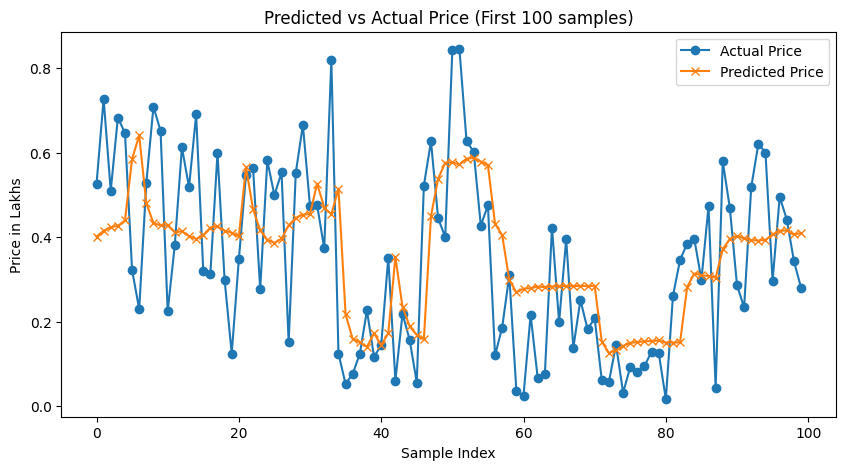

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_original[:100], label="Actual Price", marker='o')
plt.plot(y_pred[:100], label="Predicted Price", marker='x')
plt.title("Predicted vs Actual Price (First 100 samples)")
plt.xlabel("Sample Index")
plt.ylabel("Price in Lakhs")
plt.legend()
plt.show()


In [34]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R² Score: {r2:.4f}")


Test RMSE: 0.2128
Test R² Score: 0.3063


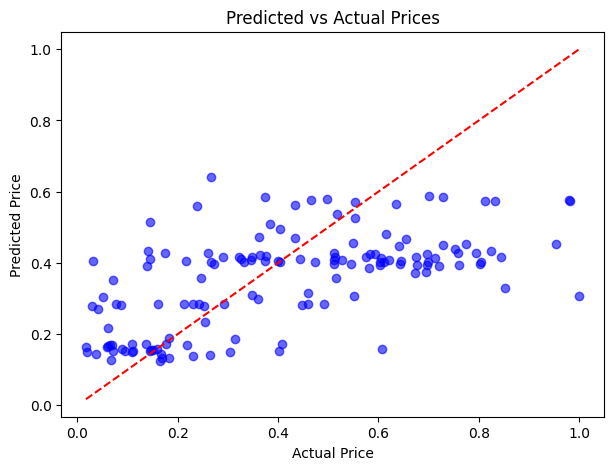

In [35]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")  # perfect line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices")
plt.show()


In [36]:
import joblib

joblib.dump(model, "real_estate_lstm_model.pkl")
print("Model saved as real_estate_lstm_model.pkl")


Model saved as real_estate_lstm_model.pkl


In [37]:
loaded_model = joblib.load("real_estate_lstm_model.pkl")


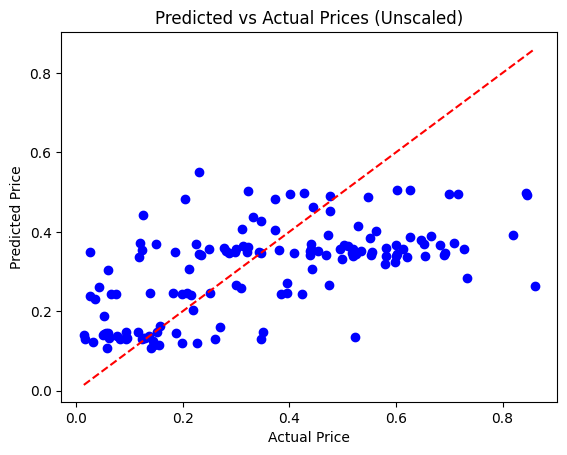

In [38]:
# Assuming you scaled y with MinMaxScaler as `scaler_y`
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)

plt.scatter(y_test_inv, y_pred_inv, color="blue")
plt.plot([y_test_inv.min(), y_test_inv.max()], 
         [y_test_inv.min(), y_test_inv.max()], 
         "r--")  # perfect prediction line
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices (Unscaled)")
plt.show()


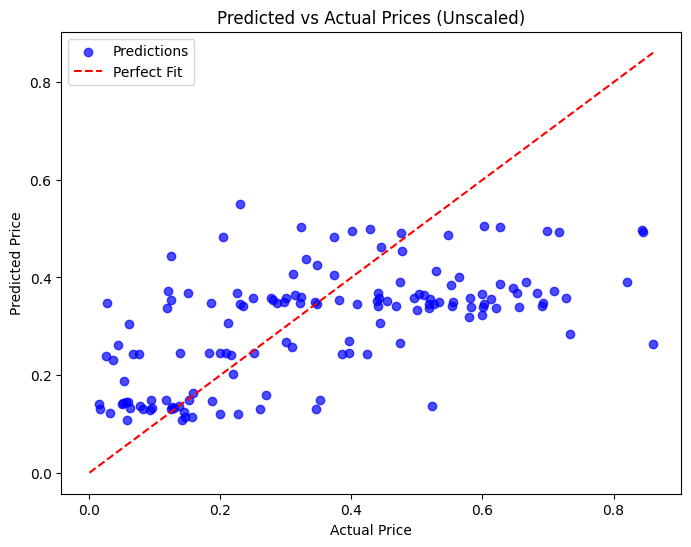

Test MAE: 0.15
Test RMSE: 0.18
Test R²: 0.3063


In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Inverse transform to get back original scale
y_test_inv = scaler_y.inverse_transform(y_test)
y_pred_inv = scaler_y.inverse_transform(y_pred)

# Scatter plot of predictions vs actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_inv, y_pred_inv, color="blue", alpha=0.7, label="Predictions")

# Perfect prediction line (y = x)
max_val = max(np.max(y_test_inv), np.max(y_pred_inv))
plt.plot([0, max_val], [0, max_val], "r--", label="Perfect Fit")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices (Unscaled)")
plt.legend()
plt.show()

# Evaluate MAE again on unscaled values
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

r2 = r2_score(y_test_inv, y_pred_inv)

print(f"Test MAE: {mae:.2f}")
print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²: {r2:.4f}")
